<a href="https://colab.research.google.com/github/Grizz1y8ee/PMML_UTS_2404220001/blob/main/Projek_UTS_PMML_2404220001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 0: Data Understanding & Preparation.

## 1. Import Library & Membaca Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Membaca dataset
df = pd.read_csv("UCI_Credit_Card.csv")

# Melihat dimensi dan informasi dasar
print("Dimensi dataset:", df.shape)
print("\nStruktur dan Tipe Data:")
df.info()

# Menampilkan 5 baris pertama
display(df.head())

Dimensi dataset: (30000, 25)

Struktur dan Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Data Understanding (Pemeriksaan Kualitas Data)

Jumlah Missing Values per kolom:
 0 missing values

Jumlah Baris Duplikat: 0

Nilai unik pada EDUCATION: {2: 14030, 1: 10585, 3: 4917, 5: 280, 4: 123, 6: 51, 0: 14}
Nilai unik pada MARRIAGE: {2: 15964, 1: 13659, 3: 323, 0: 54}

Distribusi Variabel Target (default.payment.next.month):
 default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


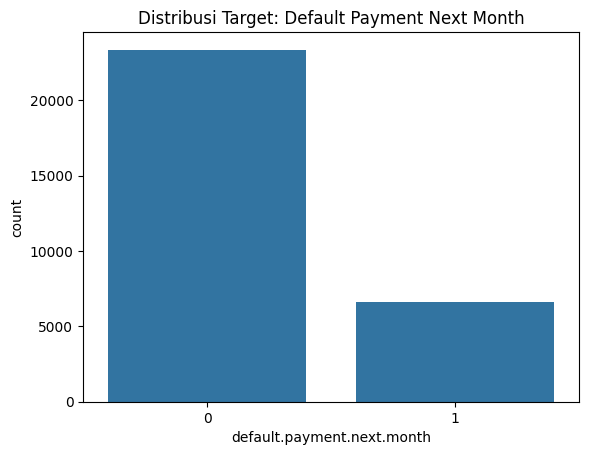

In [ ]:
print("Jumlah Missing Values per kolom:\n", df.isnull().sum().sum(), "missing values")
print("\nJumlah Baris Duplikat:", df.duplicated().sum())

# Memeriksa nilai unik pada kategori yang sering memiliki anomali
print("\nNilai unik pada EDUCATION:", df['EDUCATION'].value_counts().to_dict())
print("Nilai unik pada MARRIAGE:", df['MARRIAGE'].value_counts().to_dict())

# Melihat distribusi variabel target
target_col = 'default.payment.next.month'
print(f"\nDistribusi Variabel Target ({target_col}):\n", df[target_col].value_counts(normalize=True))

# Visualisasi Distribusi Target
sns.countplot(data=df, x=target_col)
plt.title('Distribusi Target: Default Payment Next Month')
plt.show()

## 3. Data Preparation (Pembersihan & Preprocessing Awal)

In [ ]:
# Menggabungkan kategori yang tidak wajar/tidak diketahui pada EDUCATION ke kategori 4 (Others)
# Asli: 1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown, 0=unknown
df['EDUCATION'] = df['EDUCATION'].apply(lambda x: 4 if x not in [1, 2, 3] else x)

# Menggabungkan kategori 0 pada MARRIAGE ke kategori 3 (Others)
# Asli: 1=married, 2=single, 3=others, 0=unknown
df['MARRIAGE'] = df['MARRIAGE'].apply(lambda x: 3 if x == 0 else x)

print("Kategori EDUCATION setelah dibersihkan:", df['EDUCATION'].unique())
print("Kategori MARRIAGE setelah dibersihkan:", df['MARRIAGE'].unique())

Kategori EDUCATION setelah dibersihkan: [2 1 3 4]
Kategori MARRIAGE setelah dibersihkan: [1 2 3]


4. Splitting Data (Train-Test Split)

In [ ]:
# Menentukan Predictor (X) dan Target (y)
# Variabel ID tidak digunakan sebagai predictor
X = df.drop(columns=['ID', 'default.payment.next.month'])
y = df['default.payment.next.month']

# Melakukan Train-Test Split (80% Train, 20% Test)
# stratify=y digunakan agar proporsi kelas target seimbang antara data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_test: {X_test.shape}")
print(f"Proporsi target train:\n{y_train.value_counts(normalize=True)}")
print(f"Proporsi target test:\n{y_test.value_counts(normalize=True)}")

Dimensi X_train: (24000, 23)
Dimensi X_test: (6000, 23)
Proporsi target train:
default.payment.next.month
0    0.778792
1    0.221208
Name: proportion, dtype: float64
Proporsi target test:
default.payment.next.month
0    0.778833
1    0.221167
Name: proportion, dtype: float64


# Experiment 1: Baseline Model.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Inisialisasi model Logistic Regression sebagai baseline
# max_iter ditingkatkan karena data belum di-scale sehingga butuh iterasi lebih banyak untuk konvergen
logreg_baseline = LogisticRegression(max_iter=3000, random_state=42)

# 2. Evaluasi menggunakan 5-fold Cross Validation pada training set
# Menggunakan F1-score sebagai metrik utama sesuai instruksi
cv_scores_baseline = cross_val_score(logreg_baseline, X_train, y_train, cv=5, scoring='f1')
cv_f1_baseline = cv_scores_baseline.mean()

# 3. Melatih model pada keseluruhan training set
logreg_baseline.fit(X_train, y_train)

# 4. Melakukan prediksi pada test set
y_pred_baseline = logreg_baseline.predict(X_test)

# 5. Menghitung metrik evaluasi pada test set
acc_baseline = accuracy_score(y_test, y_pred_baseline)
prec_baseline = precision_score(y_test, y_pred_baseline, zero_division=0)
rec_baseline = recall_score(y_test, y_pred_baseline)
f1_test_baseline = f1_score(y_test, y_pred_baseline)

# 6. Menampilkan Laporan Hasil
print("=== HASIL EXPERIMENT 1: BASELINE MODEL ===")
print(f"CV F1-score (5-fold) : {cv_f1_baseline:.4f}")
print(f"Test Accuracy        : {acc_baseline:.4f}")
print(f"Test Precision       : {prec_baseline:.4f}")
print(f"Test Recall          : {rec_baseline:.4f}")
print(f"Test F1-score        : {f1_test_baseline:.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

=== HASIL EXPERIMENT 1: BASELINE MODEL ===
CV F1-score (5-fold) : 0.3624
Test Accuracy        : 0.8080
Test Precision       : 0.6874
Test Recall          : 0.2419
Test F1-score        : 0.3579


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Experiment 2: Preprocessing.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Inisialisasi StandardScaler
scaler = StandardScaler()

# 2. Melakukan scaling (fit pada data train, transform pada train dan test)
# Aturan penting: Hanya gunakan .fit() pada X_train untuk mencegah data leakage!
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Inisialisasi ulang model Logistic Regression untuk data yang sudah diproses
# max_iter bisa diturunkan karena data yang terskala lebih cepat konvergen
logreg_scaled = LogisticRegression(max_iter=1000, random_state=42)

# 4. Evaluasi menggunakan 5-fold Cross Validation pada training set berskala
cv_scores_scaled = cross_val_score(logreg_scaled, X_train_scaled, y_train, cv=5, scoring='f1')
cv_f1_scaled = cv_scores_scaled.mean()

# 5. Melatih model pada keseluruhan training set berskala
logreg_scaled.fit(X_train_scaled, y_train)

# 6. Melakukan prediksi pada test set yang sudah diproses
y_pred_scaled = logreg_scaled.predict(X_test_scaled)

# 7. Menghitung metrik evaluasi
acc_scaled = accuracy_score(y_test, y_pred_scaled)
prec_scaled = precision_score(y_test, y_pred_scaled, zero_division=0)
rec_scaled = recall_score(y_test, y_pred_scaled)
f1_test_scaled = f1_score(y_test, y_pred_scaled)

# 8. Menampilkan Laporan Hasil
print("=== HASIL EXPERIMENT 2: BASELINE + PREPROCESSING (SCALING) ===")
print(f"CV F1-score (5-fold) : {cv_f1_scaled:.4f}")
print(f"Test Accuracy        : {acc_scaled:.4f}")
print(f"Test Precision       : {prec_scaled:.4f}")
print(f"Test Recall          : {rec_scaled:.4f}")
print(f"Test F1-score        : {f1_test_scaled:.4f}")

=== HASIL EXPERIMENT 2: BASELINE + PREPROCESSING (SCALING) ===
CV F1-score (5-fold) : 0.3657
Test Accuracy        : 0.8083
Test Precision       : 0.6903
Test Recall          : 0.2419
Test F1-score        : 0.3583


# Experiment 3: Model Comparison

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Inisialisasi Model
# Logistic Regression sudah kita miliki dari Experiment 2 (logreg_scaled)
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# Dictionary untuk menyimpan model
models = {
    'Logistic Regression': logreg_scaled,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

# 2. Loop untuk evaluasi setiap model
print("=== HASIL EXPERIMENT 3: MODEL COMPARISON ===")
for name, model in models.items():
    print(f"\n--- Menguji Model: {name} ---")

    # 5-fold CV
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    cv_f1 = cv_scores.mean()

    # Training & Testing
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Metrics calculation
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Menampilkan hasil
    print(f"CV F1-score (5-fold) : {cv_f1:.4f}")
    print(f"Test Accuracy        : {acc:.4f}")
    print(f"Test Precision       : {prec:.4f}")
    print(f"Test Recall          : {rec:.4f}")
    print(f"Test F1-score        : {f1:.4f}")

=== HASIL EXPERIMENT 3: MODEL COMPARISON ===

--- Menguji Model: Logistic Regression ---
CV F1-score (5-fold) : 0.3657
Test Accuracy        : 0.8083
Test Precision       : 0.6903
Test Recall          : 0.2419
Test F1-score        : 0.3583

--- Menguji Model: Decision Tree ---
CV F1-score (5-fold) : 0.3979
Test Accuracy        : 0.7197
Test Precision       : 0.3768
Test Recall          : 0.4092
Test F1-score        : 0.3923

--- Menguji Model: Random Forest ---
CV F1-score (5-fold) : 0.4673
Test Accuracy        : 0.8138
Test Precision       : 0.6411
Test Recall          : 0.3595
Test F1-score        : 0.4606


# Experiment 4: Hyperparameter Tuning.

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Menentukan parameter yang akan diuji (Hyperparameter Grid)
# Kita membatasi grid agar proses training tidak memakan waktu berjam-jam
param_grid = {
    'n_estimators': [100, 200],         # Jumlah pohon dalam hutan
    'max_depth': [10, 20, None],        # Kedalaman maksimal pohon
    'min_samples_split': [2, 5, 10]     # Minimal sampel untuk memecah node
}

# 2. Inisialisasi model dasar Random Forest
rf_base = RandomForestClassifier(random_state=42)

# 3. Setup GridSearchCV dengan 5-fold CV dan metrik F1-score
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,      # Menggunakan semua core CPU agar lebih cepat
    verbose=2       # Menampilkan progres
)

print("Memulai Hyperparameter Tuning... (Mohon tunggu, ini bisa memakan waktu 1-3 menit)")

# 4. Melatih grid search pada data training yang sudah diskalakan
grid_search.fit(X_train_scaled, y_train)

# 5. Mendapatkan model dengan hyperparameter terbaik
best_rf_model = grid_search.best_estimator_

# 6. Evaluasi model terbaik pada test set
y_pred_tuned = best_rf_model.predict(X_test_scaled)

# 7. Menghitung metrik
acc_tuned = accuracy_score(y_test, y_pred_tuned)
prec_tuned = precision_score(y_test, y_pred_tuned, zero_division=0)
rec_tuned = recall_score(y_test, y_pred_tuned)
f1_test_tuned = f1_score(y_test, y_pred_tuned)

# 8. Menampilkan Laporan Hasil Tuning
print("\n=== HASIL EXPERIMENT 4: HYPERPARAMETER TUNING (RANDOM FOREST) ===")
print("Hyperparameter yang diuji:", list(param_grid.keys()))
print("Kombinasi Hyperparameter Terbaik:", grid_search.best_params_)
print(f"Best CV F1-score     : {grid_search.best_score_:.4f}")
print(f"Test Accuracy        : {acc_tuned:.4f}")
print(f"Test Precision       : {prec_tuned:.4f}")
print(f"Test Recall          : {rec_tuned:.4f}")
print(f"Test F1-score        : {f1_test_tuned:.4f}")

Memulai Hyperparameter Tuning... (Mohon tunggu, ini bisa memakan waktu 1-3 menit)
Fitting 5 folds for each of 18 candidates, totalling 90 fits

=== HASIL EXPERIMENT 4: HYPERPARAMETER TUNING (RANDOM FOREST) ===
Hyperparameter yang diuji: ['n_estimators', 'max_depth', 'min_samples_split']
Kombinasi Hyperparameter Terbaik: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-score     : 0.4781
Test Accuracy        : 0.8140
Test Precision       : 0.6412
Test Recall          : 0.3610
Test F1-score        : 0.4619


# Experiment 5: Advanced Model.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Inisialisasi Model Advanced (Gradient Boosting)
print("=== HASIL EXPERIMENT 5: ADVANCED MODEL (GRADIENT BOOSTING) ===")
gb_model = GradientBoostingClassifier(random_state=42)

# 2. Evaluasi menggunakan 5-fold CV
cv_scores_gb = cross_val_score(gb_model, X_train_scaled, y_train, cv=5, scoring='f1')
cv_f1_gb = cv_scores_gb.mean()

# 3. Melatih model pada data training
gb_model.fit(X_train_scaled, y_train)

# 4. Melakukan prediksi pada test set
y_pred_gb = gb_model.predict(X_test_scaled)

# 5. Menghitung metrik evaluasi
acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb, zero_division=0)
rec_gb = recall_score(y_test, y_pred_gb)
f1_test_gb = f1_score(y_test, y_pred_gb)

# 6. Menampilkan Laporan Hasil
print(f"CV F1-score (5-fold) : {cv_f1_gb:.4f}")
print(f"Test Accuracy        : {acc_gb:.4f}")
print(f"Test Precision       : {prec_gb:.4f}")
print(f"Test Recall          : {rec_gb:.4f}")
print(f"Test F1-score        : {f1_test_gb:.4f}")

=== HASIL EXPERIMENT 5: ADVANCED MODEL (GRADIENT BOOSTING) ===
CV F1-score (5-fold) : 0.4782
Test Accuracy        : 0.8185
Test Precision       : 0.6657
Test Recall          : 0.3602
Test F1-score        : 0.4675
